# A convolutional network on the wafer line

Notebook 01 counted what weight sharing saves and checked that convolution is
equivariant to translation. Neither is worth anything until it is measured
against the alternative, which is lesson 9's dense network on exactly the same
images.

Four questions, and the second is the one this lesson exists for:

1. How do the two compare, head to head?
2. What happens when a defect appears somewhere the model has never seen one?
3. How much data does each need?
4. What is the convolution actually using — the *arrangement* of the pixels,
   or only the fact that one detector serves every position?

Handout sections 6 to 9.

## 1. Setup

In [1]:
# pip install numpy==1.26.4 pandas==2.1.1 matplotlib==3.8.0 scikit-learn==1.3.1 tensorflow-cpu==2.21.0

import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import tensorflow as tf
import keras
from keras import layers

from wafer_data import (make_wafer_images, make_defect_types, TRUE_IMAGE_SIZE,
                        TRUE_TOP_BAND, TRUE_BOTTOM_BAND, TRUE_DEFECT_TYPES,
                        TRUE_GRADER_ERROR_RATE)

FIGURES = Path.cwd().parent / "Figures"
FIGURES.mkdir(exist_ok=True)

BLUE, TEAL, RUST, GOLD, PLUM = "#1F4E79", "#2E8B8B", "#B4483E", "#C9A227", "#7B4B94"
tf.config.experimental.enable_op_determinism()
S = TRUE_IMAGE_SIZE

X_pool, y_pool, t_pool = make_wafer_images(seed=10001, n_images=8000)
X_test, y_test, t_test = make_wafer_images(seed=12345, n_images=2000)
print(f"training pool {X_pool.shape}, test set {X_test.shape}")
print(f"ceiling realised on the TEST set: {(y_test == t_test).mean():.4f}"
      f"   (designed {1 - TRUE_GRADER_ERROR_RATE:.2f})")

I0000 00:00:1787971765.668152   37357 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


I0000 00:00:1787971767.984754   37357 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


training pool (8000, 24, 24), test set (2000, 24, 24)
ceiling realised on the TEST set: 0.9800   (designed 0.98)


## 2. Two architectures

The dense network is lesson 9's, unchanged: flatten the image and stack two
layers of 256. The convolutional one alternates 3×3 kernels with pooling, then
takes a **global** maximum — one number per kernel, saying whether that kernel
ever fired strongly, anywhere.

In [2]:
def dense_net(seed=0, width=256, n_out=1, act="sigmoid"):
    keras.utils.set_random_seed(seed)
    model = keras.Sequential([
        keras.Input(shape=(S, S, 1)), layers.Flatten(),
        layers.Dense(width, activation="relu"),
        layers.Dense(width, activation="relu"),
        layers.Dense(n_out, activation=act)])
    model.compile(optimizer=keras.optimizers.Adam(1e-3),
                  loss="binary_crossentropy" if n_out == 1
                  else "sparse_categorical_crossentropy", metrics=["accuracy"])
    return model


def conv_net(seed=0, n_out=1, act="sigmoid"):
    keras.utils.set_random_seed(seed)
    inputs = keras.Input(shape=(S, S, 1))
    x = layers.Conv2D(8, 3, activation="relu", padding="same", name="c1")(inputs)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Conv2D(16, 3, activation="relu", padding="same", name="c2")(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.GlobalMaxPooling2D()(x)
    x = layers.Dense(16, activation="relu")(x)
    model = keras.Model(inputs, layers.Dense(n_out, activation=act)(x))
    model.compile(optimizer=keras.optimizers.Adam(1e-3),
                  loss="binary_crossentropy" if n_out == 1
                  else "sparse_categorical_crossentropy", metrics=["accuracy"])
    return model


def fit_score(build, Xtr, ytr, Xte, yte, epochs=40, seeds=2, **kw):
    scores, model = [], None
    for seed in range(seeds):
        model = build(seed=seed, **kw)
        model.fit(Xtr[..., None], ytr, epochs=epochs, batch_size=64, verbose=0)
        scores.append(model.evaluate(Xte[..., None], yte, verbose=0)[1])
    return np.mean(scores), np.std(scores), model


conv_net(0).summary()
print(f"\ndense network parameters: {dense_net(0).count_params():,}")

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 24, 24, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ c1 (Conv2D)                     │ (None, 24, 24, 8)      │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 12, 12, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ c2 (Conv2D)                     │ (None, 12, 12, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling2d            │ (None, 16)             │             0 │
│ (GlobalMaxPooling2D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,537 (6.00 KB)

 Trainable params: 1,537 (6.00 KB)

 Non-trainable params: 0 (0.00 B)


dense network parameters: 213,761


## 3. Head to head

In [3]:
head_to_head = []
for name, build in (("dense (lesson 9)", dense_net), ("convolutional", conv_net)):
    mean, sd, model = fit_score(build, X_pool[:3000], y_pool[:3000],
                                X_test, y_test)
    head_to_head.append({"network": name, "accuracy": mean, "sd": sd,
                         "parameters": model.count_params()})
head = pd.DataFrame(head_to_head).set_index("network")
head["parameters per point of accuracy"] = (
    head["parameters"] / (head["accuracy"] * 100)).round(0)
print(f"trained on 3,000 images; ceiling {(y_test == t_test).mean():.4f}\n")
head.round(4)

trained on 3,000 images; ceiling 0.9800



,accuracy,sd,parameters,parameters per point of accuracy
network,,,,
dense (lesson 9),0.6928,0.0342,213761,3086.0
convolutional,0.9800,0.0000,1537,16.0


In [4]:
best_conv = conv_net(0)
best_conv.fit(X_pool[:3000, ..., None], y_pool[:3000], epochs=40,
              batch_size=64, verbose=0)
predicted = (best_conv.predict(X_test[..., None], verbose=0).ravel() > 0.5).astype(int)
print(f"convolutional network vs the RECORDED grade: {(predicted == y_test).mean():.4f}")
print(f"convolutional network vs the TRUE grade    : {(predicted == t_test).mean():.4f}")
print(f"recorded vs true                           : {(y_test == t_test).mean():.4f}")

convolutional network vs the RECORDED grade: 0.9800
convolutional network vs the TRUE grade    : 1.0000
recorded vs true                           : 0.9800


Read the second line before the first. **The convolutional network is right
about every single die.** Its 0.98 is not a modelling shortfall at all — it is
the grading station's 2% error rate, in full, and nothing else. There is no
gap left for a better architecture to close.

The dense network, on the same images, is thirty points behind with a hundred
and forty times more parameters. This is the comparison the whole lesson turns
on, and it is worth being precise about *why* it comes out this way, because
"convolution is better for images" is not a reason. Section 5 supplies one.

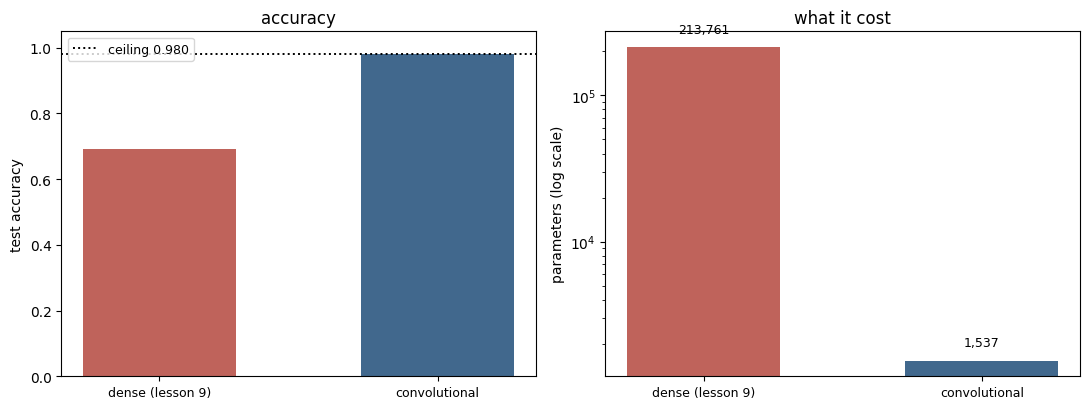

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.2))
names = list(head.index)
axes[0].bar(names, head["accuracy"], color=[RUST, BLUE], alpha=.85, width=.55)
axes[0].axhline((y_test == t_test).mean(), color="k", ls=":", lw=1.4,
                label=f"ceiling {(y_test == t_test).mean():.3f}")
axes[0].set_ylabel("test accuracy")
axes[0].set_ylim(0, 1.05)
axes[0].legend(fontsize=9)
axes[0].set_title("accuracy")
axes[1].bar(names, head["parameters"], color=[RUST, BLUE], alpha=.85, width=.55)
axes[1].set_yscale("log")
axes[1].set_ylabel("parameters (log scale)")
axes[1].set_title("what it cost")
for ax in axes:
    ax.tick_params(axis="x", labelsize=9)
for i, v in enumerate(head["parameters"]):
    axes[1].text(i, v * 1.25, f"{v:,}", ha="center", fontsize=9)
fig.tight_layout()
fig.savefig(FIGURES / "dense_vs_conv.png", dpi=150)
plt.show()

## 4. A defect where none has been seen

This is the experiment. Defects are confined to a **band of rows** — the top
of the die for training, the bottom for one of the two test sets. Nothing else
changes: same generator, same defect, same contrast, same number of images.

A model that has learned *what a scratch looks like* will not care. A model
that has learned *what a scratch looks like in rows 5 to 11* will.

In [6]:
X_top, y_top, _ = make_wafer_images(seed=11001, n_images=3000, band=TRUE_TOP_BAND)
X_top_te, y_top_te, _ = make_wafer_images(seed=11003, n_images=1500, band=TRUE_TOP_BAND)
X_bot_te, y_bot_te, _ = make_wafer_images(seed=11002, n_images=1500, band=TRUE_BOTTOM_BAND)

moved = []
for name, build in (("dense (lesson 9)", dense_net), ("convolutional", conv_net)):
    same, _, _ = fit_score(build, X_top, y_top, X_top_te, y_top_te)
    other, _, _ = fit_score(build, X_top, y_top, X_bot_te, y_bot_te)
    moved.append({"network": name, "defect in the trained band": same,
                  "defect moved to the other half": other,
                  "cost of moving it": other - same})
moved = pd.DataFrame(moved).set_index("network")
moved.round(4)

,defect in the trained band,defect moved to the other half,cost of moving it
network,,,
dense (lesson 9),0.8567,0.4617,-0.3950
convolutional,0.9800,0.9847,0.0047


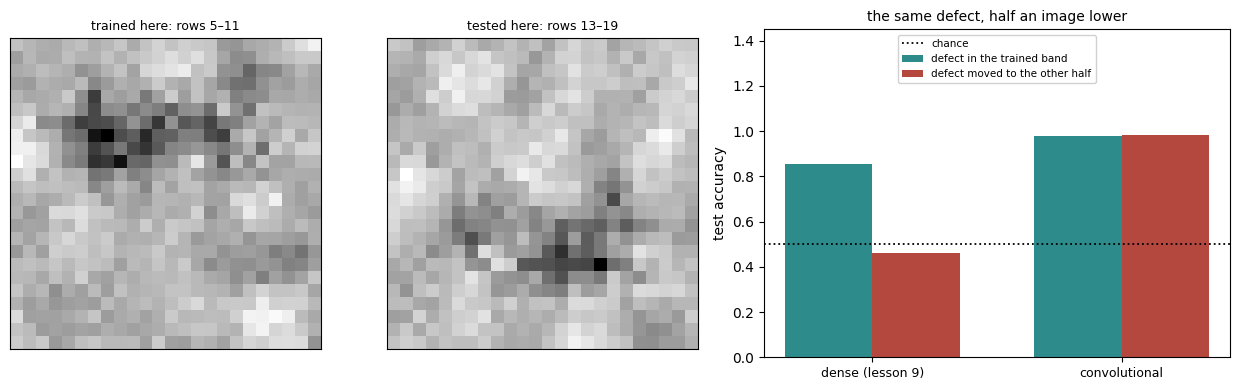

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(12.5, 4.0),
                         gridspec_kw={"width_ratios": [1, 1, 1.5]})
for ax, (Xa, ya, title) in zip(axes[:2], (
        (X_top, y_top, f"trained here: rows {TRUE_TOP_BAND[0]}–{TRUE_TOP_BAND[1]}"),
        (X_bot_te, y_bot_te, f"tested here: rows {TRUE_BOTTOM_BAND[0]}–{TRUE_BOTTOM_BAND[1]}"))):
    ax.imshow(Xa[ya == 1][:40].mean(axis=0), cmap="gray")
    ax.set_title(title, fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])

ax = axes[2]
width = 0.35
spots = np.arange(len(moved))
ax.bar(spots - width / 2, moved["defect in the trained band"], width,
       color=TEAL, label="defect in the trained band")
ax.bar(spots + width / 2, moved["defect moved to the other half"], width,
       color=RUST, label="defect moved to the other half")
ax.axhline(0.5, color="k", ls=":", lw=1.3, label="chance")
ax.set_xticks(spots)
ax.set_xticklabels(moved.index, fontsize=9)
ax.set_ylabel("test accuracy")
# Headroom above the tallest bar, so the legend covers nothing. At
# loc="lower left" it sat across the base of both dense bars and the tick
# label under them.
ax.set_ylim(0, 1.45)
ax.legend(fontsize=7.5, loc="upper center", framealpha=0.9)
ax.set_title("the same defect, half an image lower", fontsize=10)
fig.tight_layout()
fig.savefig(FIGURES / "translation_test.png", dpi=150)
plt.show()

The left panels average forty defective dies from each band, so the bright
smear is where the defects were. The right panel is the result.

**The dense network falls to chance.** It scored well while the defect stayed
where it had been seen, and moving that identical defect half an image down
destroys it — not degrades it, destroys it. Every one of its 576 first-layer
weights per unit is attached to a specific pixel, and the pixels carrying the
evidence are now different pixels.

**The convolutional network does not move at all.** It was never told where to
look, because the question it asks is asked everywhere.

This is what an *inductive bias* is, made measurable. Convolution is not a
better function approximator than a dense layer — it is a **worse** one, in
the strict sense that it can express strictly fewer functions. That restriction
is the whole point: the functions it gives up are the ones that treat position
5 differently from position 15, and on this problem none of those were wanted.

## 5. Can augmentation buy the same thing?

If the dense network's problem is that it never saw a defect low on the die,
one obvious repair is to show it some — by shifting the training images it
already has. **Data augmentation** applies transformations the label is known
to survive: a scratch moved three pixels is still a scratch.

In [8]:
def augment(images, labels, copies=4, max_shift=10, seed=0):
    """Extra training images, each one rolled by its OWN random offset.

    Sampling one offset per copy and applying it to the whole batch would add
    four more fixed positions, which is not augmentation — it is four more
    special cases. Every image needs its own draw.
    """
    rng = np.random.default_rng(seed)
    out_x, out_y = [images], [labels]
    for _ in range(copies):
        shifted = np.empty_like(images)
        offsets = rng.integers(-max_shift, max_shift + 1, (len(images), 2))
        for i, (dr, dc) in enumerate(offsets):
            shifted[i] = np.roll(np.roll(images[i], dr, axis=0), dc, axis=1)
        out_x.append(shifted)
        out_y.append(labels)
    return np.concatenate(out_x), np.concatenate(out_y)


X_aug, y_aug = augment(X_top, y_top)
print(f"{len(X_top)} training images become {len(X_aug)} after augmentation\n")

augmented = []
for name, build in (("dense (lesson 9)", dense_net), ("convolutional", conv_net)):
    plain, _, _ = fit_score(build, X_top, y_top, X_bot_te, y_bot_te)
    grown, _, _ = fit_score(build, X_aug, y_aug, X_bot_te, y_bot_te)
    augmented.append({"network": name, "trained on the top band only": plain,
                      "with shifted copies added": grown,
                      "gain": grown - plain})
augmented = pd.DataFrame(augmented).set_index("network")
augmented.round(4)

3000 training images become 15000 after augmentation



,trained on the top band only,with shifted copies added,gain
network,,,
dense (lesson 9),0.4617,0.5423,0.0807
convolutional,0.9847,0.9847,0.0000


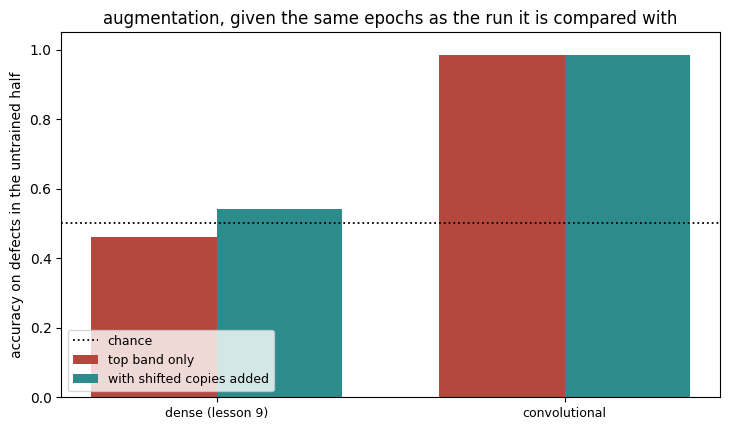

In [9]:
fig, ax = plt.subplots(figsize=(7.4, 4.4))
spots = np.arange(len(augmented))
ax.bar(spots - 0.18, augmented["trained on the top band only"], 0.36,
       color=RUST, label="top band only")
ax.bar(spots + 0.18, augmented["with shifted copies added"], 0.36,
       color=TEAL, label="with shifted copies added")
ax.axhline(0.5, color="k", ls=":", lw=1.3, label="chance")
ax.set_xticks(spots)
ax.set_xticklabels(augmented.index, fontsize=9)
ax.set_ylabel("accuracy on defects in the untrained half")
ax.set_ylim(0, 1.05)
ax.legend(fontsize=9, loc="lower left")
ax.set_title("augmentation, given the same epochs as the run it is compared with")
fig.tight_layout()
fig.savefig(FIGURES / "augmentation.png", dpi=150)
plt.show()

**Augmentation helps, and it does not come close.** Five times the training
data, every copy shifted by its own random offset, the same epoch budget as
the run it is compared against — and the dense network climbs about eight
points, from 0.46 to 0.54. Real, measurable, and still forty-four points
behind what the convolutional network gets for nothing.

Why so little for so much data? Because augmentation has to *teach* the
invariance one example at a time, and the dense network then has to spend
capacity storing it — a separate detector for every position a defect might
occupy. Section 6 measures what that costs: at 8,000 unshifted images the
dense network is still 24 points below the ceiling on the *easier* version of
this task, where defects were never restricted to a band at all. Fifteen
thousand shifted images were never going to close a gap that size.

Two details of this comparison are worth copying rather than the result. Both
arms got the **same number of epochs** — an augmented set is five times
larger, so giving it the same *wall-clock* budget would have quietly handed it
five times fewer passes over each image. And the shifts are drawn **per
image**, not per batch: one offset applied to a whole copy adds four more
fixed positions, which is four more special cases rather than augmentation.

The distinction to carry away is therefore sharper than "both work":

**Architecture asserts the invariance.** It costs nothing at training time, it
cannot be forgotten, and it is exact.

**Augmentation approximates it from examples.** It is the tool for invariances
you cannot express in a layer — brightness, contrast, small rotations, elastic
distortion — and for those it is indispensable. It is a poor substitute for an
invariance a layer *can* express, which translation is.

## 6. How much data does each one need?

In [10]:
sizes = (100, 200, 500, 1000, 3000, 8000)
curve = {}
for name, build in (("dense (lesson 9)", dense_net), ("convolutional", conv_net)):
    curve[name] = [fit_score(build, X_pool[:n], y_pool[:n], X_test, y_test)[0]
                   for n in sizes]
efficiency = pd.DataFrame(curve, index=sizes)
efficiency.index.name = "training images"
efficiency.round(4)

,dense (lesson 9),convolutional
training images,,
100,0.5643,0.7383
200,0.5510,0.8765
500,0.6303,0.9800
1000,0.6385,0.9800
3000,0.6928,0.9800
8000,0.7455,0.9800


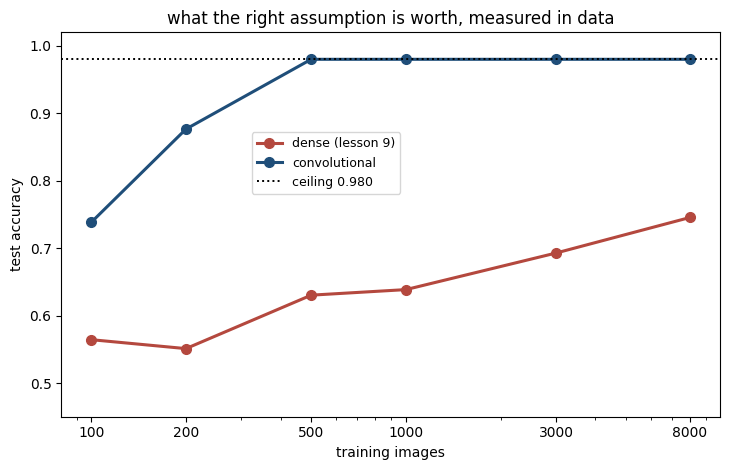

the convolutional network reaches the ceiling at 500 images
the dense network, at 8000, is still 0.235 short


In [11]:
fig, ax = plt.subplots(figsize=(7.4, 4.8))
for (name, values), colour in zip(efficiency.items(), (RUST, BLUE)):
    ax.plot(sizes, values, "o-", color=colour, lw=2.2, ms=7, label=name)
ax.axhline((y_test == t_test).mean(), color="k", ls=":", lw=1.4,
           label=f"ceiling {(y_test == t_test).mean():.3f}")
ax.set_xscale("log")
ax.set_xticks(sizes)
ax.set_xticklabels(sizes)
ax.set_xlabel("training images")
ax.set_ylabel("test accuracy")
ax.set_ylim(0.45, 1.02)
ax.legend(fontsize=9, loc="center left", bbox_to_anchor=(0.28, 0.66))
ax.set_title("what the right assumption is worth, measured in data")
fig.tight_layout()
fig.savefig(FIGURES / "sample_efficiency.png", dpi=150)
plt.show()

conv_at = next(n for n, v in zip(sizes, efficiency["convolutional"])
               if v >= (y_test == t_test).mean() - 0.005)
print(f"the convolutional network reaches the ceiling at {conv_at} images")
print(f"the dense network, at {sizes[-1]}, is still "
      f"{(y_test == t_test).mean() - efficiency['dense (lesson 9)'].iloc[-1]:.3f} short")

## 7. What is the convolution actually using?

Here is the experiment that says what a convolutional network is really
exploiting, and its answer is not the one the textbook slogan suggests.

Apply **one fixed permutation** to the pixel positions of every image, train
and test on the shuffled version. Lesson 9's closing paragraph says the dense
network cannot possibly notice, because it never used the arrangement. What
should happen to the convolution, whose kernels are defined entirely by
adjacency?

Run it on two different tasks: grading a die **defective or not**, and naming
**which of three types** of defect it carries.

In [12]:
permutation = np.random.default_rng(10003).permutation(S * S)


def shuffle(images):
    return images.reshape(len(images), -1)[:, permutation].reshape(-1, S, S)


X_type, y_type = make_defect_types(seed=10005, n_images=6000)
X_type_te, y_type_te = make_defect_types(seed=10077, n_images=2000)

rows = []
tasks = (("is there a defect?", X_pool[:3000], y_pool[:3000], X_test, y_test, 1, "sigmoid"),
         ("which defect is it?", X_type, y_type, X_type_te, y_type_te, 3, "softmax"))
for task, Xa, ya, Xb, yb, n_out, act in tasks:
    for arrangement, fa, fb in (("as photographed", lambda a: a, lambda b: b),
                                ("pixels permuted", shuffle, shuffle)):
        for name, build in (("dense", dense_net), ("convolutional", conv_net)):
            mean, sd, _ = fit_score(build, fa(Xa), ya, fb(Xb), yb,
                                    epochs=30, n_out=n_out, act=act)
            rows.append({"task": task, "pixels": arrangement, "network": name,
                         "accuracy": mean, "sd": sd})
permuted = pd.DataFrame(rows).set_index(["task", "network", "pixels"])
permuted.round(4)

accuracy      sd
task                network       pixels                           
is there a defect?  dense         as photographed    0.6985  0.0350
                    convolutional as photographed    0.9798  0.0003
                    dense         pixels permuted    0.7097  0.0138
                    convolutional pixels permuted    0.9800  0.0000
which defect is it? dense         as photographed    0.6615  0.0055
                    convolutional as photographed    0.9970  0.0005
                    dense         pixels permuted    0.6478  0.0123
                    convolutional pixels permuted    0.9523  0.0077

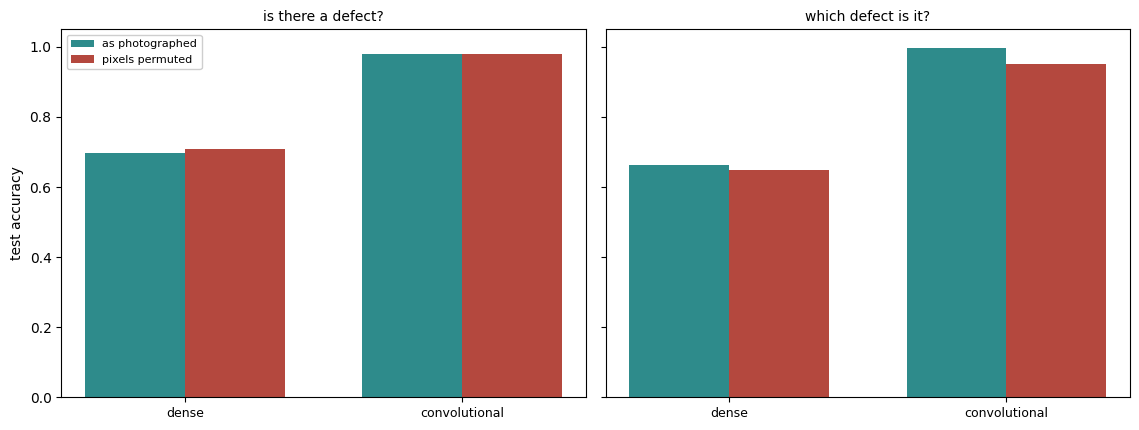

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.4), sharey=True)
flat = permuted.reset_index()
for ax, task in zip(axes, flat["task"].unique()):
    block = flat[flat["task"] == task]
    spots = np.arange(2)
    for offset, arrangement, colour in ((-0.18, "as photographed", TEAL),
                                        (0.18, "pixels permuted", RUST)):
        vals = [block[(block["network"] == n)
                      & (block["pixels"] == arrangement)]["accuracy"].iloc[0]
                for n in ("dense", "convolutional")]
        ax.bar(spots + offset, vals, 0.36, color=colour, label=arrangement)
    ax.set_xticks(spots)
    ax.set_xticklabels(["dense", "convolutional"], fontsize=9)
    ax.set_title(task, fontsize=10)
    ax.set_ylim(0, 1.05)
axes[0].set_ylabel("test accuracy")
axes[0].legend(fontsize=8, loc="upper left", framealpha=0.95)
fig.tight_layout()
fig.savefig(FIGURES / "permutation_test.png", dpi=150)
plt.show()

Three readings, and the middle one is the surprise.

**The dense network does not notice, on either task.** Exactly as lesson 9
predicted. Permuting the pixels is, for a dense layer, a relabelling of input
units and nothing more.

**On "is there a defect?", the convolution does not notice either.** That looks
wrong until you ask what the task actually needs. To grade a die you must
answer "is there a small patch of unusual local contrast *anywhere*" — and a
scattered permutation still leaves that patch's pixels somewhere, still
extreme. The convolution is winning this task on **weight sharing** alone: one
detector, applied at every position. It never needed the arrangement.

**On "which defect is it?", it notices.** Telling a scratch from a particle is
a question about *shape* — a line against a blob — and shape is exactly what
the permutation destroys.

So convolution bundles two separate assumptions, and this is the one place in
the lesson where they can be seen apart:

| assumption | what it says | which task needed it |
|---|---|---|
| weight sharing | a pattern means the same thing wherever it appears | both |
| locality | nearby pixels belong together | only the typing task |

The usual summary — "convolutions work on images because images have spatial
structure" — is true but blurred. On this data, most of the advantage came
from the first assumption, and only naming the defect type required the
second.

## 8. What the first layer learned

Eight kernels of nine numbers each. Nothing told them what to look for.

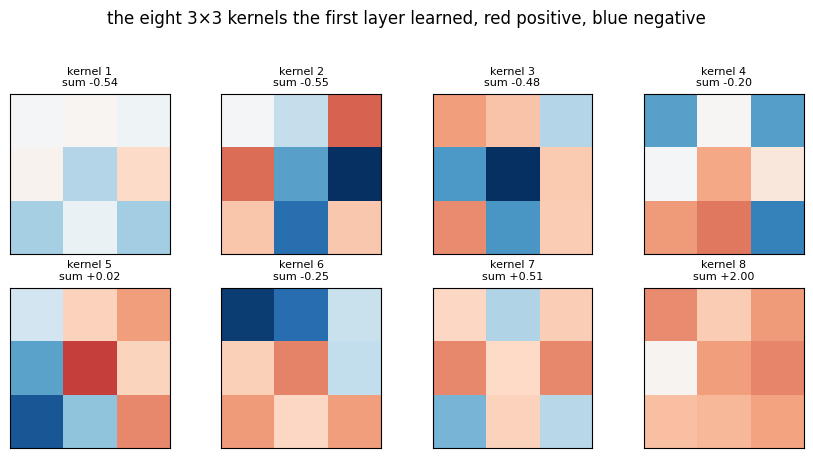

kernel weight sums: [-0.54 -0.55 -0.48 -0.2   0.02 -0.25  0.51  2.  ]
mean |sum| = 0.571, against a mean |weight| of 0.240 times nine = 2.163

7 of the 8 kernels sum to less than 0.6 in absolute value,
against a scale of 2.16 if their weights all pointed the same way.
A kernel summing near zero ignores flat brightness and reports only
local contrast — the property notebook 01 wrote down by hand. Not all
of them do it, and nothing required them to.


In [14]:
learned = best_conv.get_layer("c1").get_weights()[0][:, :, 0, :]
fig, axes = plt.subplots(2, 4, figsize=(8.6, 4.4))
for k, ax in enumerate(axes.ravel()):
    ax.imshow(learned[:, :, k], cmap="RdBu_r",
              vmin=-np.abs(learned).max(), vmax=np.abs(learned).max())
    ax.set_title(f"kernel {k + 1}\nsum {learned[:, :, k].sum():+.2f}", fontsize=8)
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle("the eight 3×3 kernels the first layer learned, red positive, blue negative",
             y=1.03)
fig.tight_layout()
fig.savefig(FIGURES / "learned_kernels.png", dpi=150, bbox_inches="tight")
plt.show()

sums = learned.sum(axis=(0, 1))
print(f"kernel weight sums: {np.array2string(sums, precision=2)}")
print(f"mean |sum| = {np.abs(sums).mean():.3f}, against a mean |weight| of "
      f"{np.abs(learned).mean():.3f} times nine = {np.abs(learned).mean()*9:.3f}")
near_zero = int((np.abs(sums) < 0.6).sum())
print(f"\n{near_zero} of the 8 kernels sum to less than 0.6 in absolute value,")
print("against a scale of 2.16 if their weights all pointed the same way.")
print("A kernel summing near zero ignores flat brightness and reports only")
print("local contrast — the property notebook 01 wrote down by hand. Not all")
print("of them do it, and nothing required them to.")

## Summary

- On the same 3,000 images, the dense network scores about 0.70 and the
  convolutional one **0.9800** — which is the grading station's error rate
  exactly, because against the *true* grade the convolutional network is right
  about **every die**.
- It does that with 1,537 parameters against 213,761. The saving is not the
  point; the shared evidence is.
- **Move a defect to a half of the die where none was seen in training and the
  dense network falls to chance**, while the convolutional one does not move.
  That is an inductive bias made visible: convolution can express *fewer*
  functions, and the ones it gives up are the ones nobody wanted.
- Augmentation, done properly and given equal epochs, bought the dense network
  eight points — and left it forty-four short of the convolutional network. It
  teaches an invariance one example at a time; the architecture asserts it.
  Use augmentation for invariances no layer can express, not as a substitute
  for one that can.
- The convolutional network reaches the ceiling from a few hundred images; the
  dense one has not reached it with 8,000.
- Permuting the pixels costs the convolution **nothing** on defect detection
  and several points on defect typing. Weight sharing and locality are two
  assumptions, and only the second is about arrangement.

Notebook 03 asks what happens when a new defect appears and there are forty
pictures of it.